## Obtaining data

In [1]:
import os
import datetime

import psycopg2
import pandas as pd
import numpy as np

In [2]:
conn = psycopg2.connect(
    dbname=os.environ['POSTGRES_DB_NAME'], 
    user=os.environ['POSTGRES_USER'], 
    password=os.environ['POSTGRES_PASSWORD'], 
    host=os.environ['POSTGRES_HOST'], 
    port=os.environ['POSTGRES_PORT']
)

### Test dataset

In [3]:
clients_query = """
    SELECT *
    FROM marketing_campaign.clients cl
"""
test_df = pd.read_sql(clients_query, conn)
test_df['month'] = test_df['month'].apply(lambda d: datetime.datetime.strptime(d, '%b').month)
test_df

/tmp/ipykernel_5336/4290345109.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  test_df = pd.read_sql(clients_query, conn)


,client_id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
0,1,58.0,management,married,tertiary,False,2143,True,False,unknown,5,5,261,1,False
1,2,44.0,technician,single,secondary,False,29,True,False,unknown,5,5,151,1,False
2,3,33.0,entrepreneur,married,secondary,False,2,True,True,unknown,5,5,76,1,False
3,4,47.0,blue-collar,married,unknown,False,1506,True,False,unknown,5,5,92,1,False
4,5,33.0,unknown,single,unknown,False,1,False,False,unknown,5,5,198,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,45207,51.0,technician,married,tertiary,False,825,False,False,cellular,17,11,977,3,True
45207,45208,71.0,retired,divorced,primary,False,1729,False,False,cellular,17,11,456,2,True
45208,45209,72.0,retired,married,secondary,False,5715,False,False,cellular,17,11,1127,5,True
45209,45210,57.0,blue-collar,married,secondary,False,668,False,False,telephone,17,11,508,4,False


## Ground truth dataset

In [4]:
contacts_count_query = """
    SELECT 
        cl.client_id, count(ca) as campaign
    FROM 
        marketing_campaign.clients cl
    LEFT JOIN 
        marketing_campaign.campaigns ca ON cl.client_id = ca.client_id
    GROUP BY 
        cl.client_id
"""
contacts_count = pd.read_sql(contacts_count_query, conn)

/tmp/ipykernel_5336/307892885.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  contacts_count = pd.read_sql(contacts_count_query, conn)


In [5]:
last_outcome_query = """
    WITH LatestContact AS (
        SELECT
            ca.client_id,
            ca.contact_date,
            ca.contact_outcome,
            ROW_NUMBER() OVER (PARTITION BY ca.client_id ORDER BY ca.contact_date DESC) AS rn
        FROM
            marketing_campaign.campaigns ca
    )
    SELECT 
        cl.client_id, lc.contact_outcome
    FROM 
        marketing_campaign.clients cl
    LEFT JOIN 
        LatestContact lc ON cl.client_id = lc.client_id AND lc.rn = 1;
"""
last_outcome = pd.read_sql(last_outcome_query, conn)

/tmp/ipykernel_5336/1247663759.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  last_outcome = pd.read_sql(last_outcome_query, conn)


In [6]:
first_contact_query = """
    WITH FirstContact AS (
        SELECT
            ca.client_id,
            ca.contact_date,
            ca.contact_outcome,
            ROW_NUMBER() OVER (PARTITION BY ca.client_id ORDER BY ca.contact_date ASC) AS rn
        FROM
            marketing_campaign.campaigns ca
    )
    SELECT 
        cl.client_id, lc.contact_date as first_contact
    FROM 
        marketing_campaign.clients cl
    LEFT JOIN 
        FirstContact lc ON cl.client_id = lc.client_id AND lc.rn = 1;
"""
first_contact = pd.read_sql(first_contact_query, conn)

/tmp/ipykernel_5336/3605622783.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  first_contact = pd.read_sql(first_contact_query, conn)


In [7]:
ground_df = last_outcome.dropna().merge(
    test_df.drop(['campaign', 'day', 'month'], axis=1), 
    on='client_id', 
    how='left'
).merge(
    contacts_count,
    on='client_id', 
    how='left'
).merge(
    first_contact,
    on='client_id', 
    how='left'
)
ground_df['month'] = ground_df['first_contact'].apply(lambda d: d.month)
ground_df['day'] = ground_df['first_contact'].apply(lambda d: d.day)
ground_df.drop('first_contact', axis=1, inplace=True)
ground_df

,client_id,contact_outcome,age,job,marital,education,default,balance,housing,loan,contact,duration,y,campaign,month,day
0,24061,failure,33.0,admin.,married,tertiary,False,882,False,False,telephone,39,False,3,3,19
1,24063,other,42.0,admin.,single,secondary,False,-247,True,True,telephone,519,True,1,5,8
2,24065,failure,33.0,services,married,secondary,False,3444,True,False,telephone,144,True,4,5,1
3,24073,other,36.0,management,married,tertiary,False,2415,True,False,telephone,73,False,4,5,26
4,24078,failure,36.0,management,married,tertiary,False,0,True,False,telephone,140,True,3,3,18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8252,45200,other,34.0,blue-collar,single,secondary,False,1475,True,False,cellular,1166,False,12,3,29
8253,45202,success,53.0,management,married,tertiary,False,583,False,False,cellular,226,True,4,3,4
8254,45205,failure,73.0,retired,married,secondary,False,2850,False,False,cellular,300,True,8,7,15
8255,45209,success,72.0,retired,married,secondary,False,5715,False,False,cellular,1127,True,3,2,16


## Data cleanup

In [8]:
import io

b1, b2 = io.StringIO(), io.StringIO()
test_df.info(buf=b1), ground_df.info(buf=b2)
b1, b2 = b1.getvalue(), b2.getvalue()

print('\n'.join(['{0:60}  {1}'.format(s1, s2) for s1, s2 in zip(b1.split('\n'), b2.split('\n'))]))

<class 'pandas.core.frame.DataFrame'>                         <class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210                         RangeIndex: 8257 entries, 0 to 8256
Data columns (total 15 columns):                              Data columns (total 16 columns):
 #   Column     Non-Null Count  Dtype                          #   Column           Non-Null Count  Dtype  
---  ------     --------------  -----                         ---  ------           --------------  -----  
 0   client_id  45211 non-null  int64                          0   client_id        8257 non-null   int64  
 1   age        45207 non-null  float64                        1   contact_outcome  8257 non-null   object 
 2   job        45211 non-null  object                         2   age              8257 non-null   float64
 3   marital    45211 non-null  object                         3   job              8257 non-null   object 
 4   education  45211 non-null  object                     

In [9]:
# We can fill empty age values with median from `test_df` since we posess the actual information about all the clients here
test_df.fillna(test_df['age'].median(), inplace=True)

In [10]:
# Better to drop 'NaN' strings from both datasets (there are few of them)
print(f"{ground_df['marital'].value_counts()['NaN']=}\n{test_df['marital'].value_counts()['NaN']=}")

ground_df['marital'].value_counts()['NaN']=1
test_df['marital'].value_counts()['NaN']=3


In [11]:
# On the one hand it is a problem since we wont get predictions for these customers
# On the other hand such entries are inapropriate, therefore we decide to drop them
test_df = test_df[test_df['marital'] != 'NaN']
ground_df = ground_df[ground_df['marital'] != 'NaN']

In [12]:
test_df.drop('client_id', axis=1, inplace=True)
ground_df.drop('client_id', axis=1, inplace=True)

/tmp/ipykernel_5336/3469149893.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.drop('client_id', axis=1, inplace=True)
/tmp/ipykernel_5336/3469149893.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ground_df.drop('client_id', axis=1, inplace=True)


In [13]:
# There's also few entries with unknown contact outcomes and we drop them because otherwise we would have strongly imbalanced dataset
ground_df['contact_outcome'].value_counts()

contact_outcome
failure    4900
other      1840
success    1511
unknown       5
Name: count, dtype: int64

In [14]:
ground_df = ground_df[ground_df['contact_outcome'] != 'unknown']

## Data exploration

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

In [16]:
CATEGORICAL_FEATURES = [
    'job', 'marital', 'education', 'default',
    'housing', 'loan', 'contact', 'y'
]
NUMERICAL_FEATURES = [
    'age', 'balance', 'duration', 
    'campaign', 'month', 'day'
]
TARGET = 'contact_outcome'

In [17]:
ground_df[CATEGORICAL_FEATURES].T.apply(lambda row: list(row.unique()), axis=1).to_dict()

{'job': ['admin.',
  'services',
  'management',
  'technician',
  'blue-collar',
  'unemployed',
  'entrepreneur',
  'housemaid',
  'retired',
  'self-employed',
  'unknown',
  'student'],
 'marital': ['married', 'single', 'divorced'],
 'education': ['tertiary', 'secondary', 'primary', 'unknown'],
 'default': [False, True],
 'housing': [False, True],
 'loan': [False, True],
 'contact': ['telephone', 'unknown', 'cellular'],
 'y': [False, True]}

### Correllation analysis

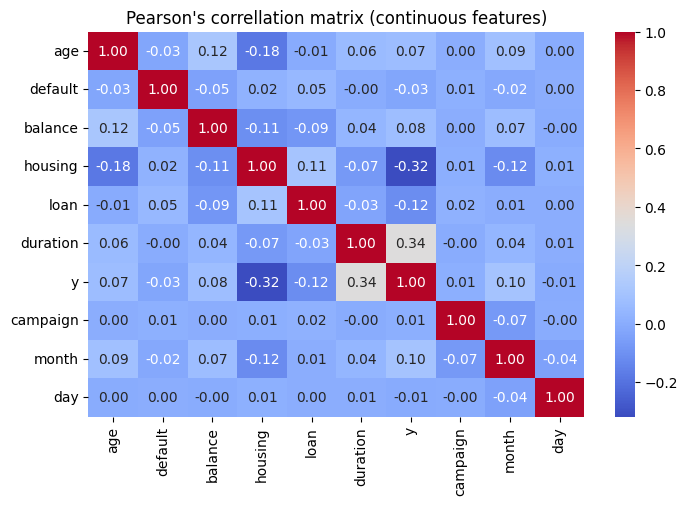

In [18]:
plt.figure(figsize=(8, 5))
sns.heatmap(ground_df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Pearson's correllation matrix (continuous features)")
plt.show()

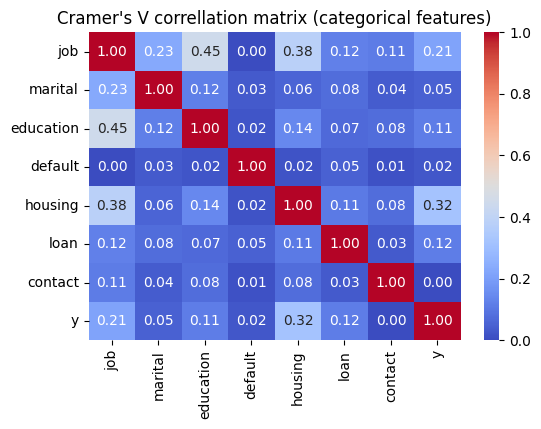

In [19]:
from copy import deepcopy

from sklearn.preprocessing import LabelEncoder
from scipy.stats import chi2_contingency

def cramers_v(vector_1, vector_2):
    confusion_matrix = pd.crosstab(vector_1, vector_2)
    chi2 = chi2_contingency(confusion_matrix)[0]
    
    n = confusion_matrix.to_numpy().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape

    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    
    return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))

ctg_df = deepcopy(ground_df)[CATEGORICAL_FEATURES]
label_encoders = {}
for feature in CATEGORICAL_FEATURES:
    le = LabelEncoder()
    ctg_df[feature] = le.fit_transform(ctg_df[feature])
    label_encoders[feature] = le

plt.figure(figsize=(6, 4))
sns.heatmap(ctg_df.corr(method=cramers_v), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Cramer's V correllation matrix (categorical features)")
plt.show()